In [2]:
# import necessary libraries
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision import transforms, datasets
from torch.utils.data import DataLoader

In [3]:
#setting device and folers
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

os.makedirs("../models", exist_ok=True)
os.makedirs("../results", exist_ok=True)

Using: cpu


In [4]:
# define paths and hyperparameters

TRAIN_PATH = "../data/DATASET/train"
TEST_PATH = "../data/DATASET/test"

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_CLASSES = 7
EPOCHS = 50

In [5]:
# define image transformations

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [6]:
# loading datasets 

train_dataset = datasets.ImageFolder(TRAIN_PATH, transform=train_transform)
test_dataset = datasets.ImageFolder(TEST_PATH, transform=test_transform)

print("Train images:", len(train_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)

Train images: 12271
Test images: 3068
Classes: ['1', '2', '3', '4', '5', '6', '7']
Class to index: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6}


In [7]:
# loading dataloaders

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 192
Validation batches: 48


In [8]:
# compute class weights for imbalanced dataset

targets = np.array(train_dataset.targets)
unique, counts = np.unique(targets, return_counts=True)

class_weights = 1.0 / torch.tensor(counts, dtype=torch.float)
class_weights = class_weights / class_weights.sum() * len(unique)
class_weights = class_weights.to(device)

print("Class counts:", dict(zip(unique, counts)))
print("Class weights:", class_weights)

Class counts: {np.int64(0): np.int64(1290), np.int64(1): np.int64(281), np.int64(2): np.int64(717), np.int64(3): np.int64(4772), np.int64(4): np.int64(1982), np.int64(5): np.int64(705), np.int64(6): np.int64(2524)}
Class weights: tensor([0.6572, 3.0168, 1.1823, 0.1776, 0.4277, 1.2025, 0.3359])


In [9]:
# define the CNN model

class EmotionCNNBaseline(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
# create model instance and move to device
model = EmotionCNNBaseline().to(device)
print(model)

EmotionCNNBaseline(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True,

In [11]:
# define training components

best_val_acc = 0
patience = 7
patience_counter = 0

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_acc": []
}

model_save_path = "../models/emotion_cnn_baseline.pth"
history_save_path = "../results/emotion_cnn_baseline_history.csv"
curve_save_path = "../results/emotion_cnn_baseline_curve.png"

loss_fn = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

In [12]:
#training cnn baseline model with early stopping and model checkpointing

for epoch in range(EPOCHS):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for i, (batch_X, batch_y) in enumerate(train_loader):
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        preds = model(batch_X)
        loss = loss_fn(preds, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_X.size(0)

        _, predicted = torch.max(preds, 1)
        correct += (predicted == batch_y).sum().item()
        total += batch_y.size(0)

        if i % 50 == 0:
            print(f"Epoch {epoch+1} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    train_loss = total_loss / len(train_loader.dataset)
    train_acc = correct / total

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            preds = model(batch_X)
            _, predicted = torch.max(preds, 1)

            correct += (predicted == batch_y).sum().item()
            total += batch_y.size(0)

    val_acc = correct / total

    history["epoch"].append(epoch + 1)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}, "
        f"Loss: {train_loss:.3f}, "
        f"Train Acc: {train_acc:.3f}, "
        f"Val Acc: {val_acc:.3f}"
    )

    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_save_path)
        print(f"New best CNN baseline saved! Val Acc: {val_acc:.3f}")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

print(f"Best CNN baseline validation accuracy: {best_val_acc:.3f}")

Epoch 1 | Batch 0/192 | Loss: 2.3057
Epoch 1 | Batch 50/192 | Loss: 1.8834
Epoch 1 | Batch 100/192 | Loss: 2.2557
Epoch 1 | Batch 150/192 | Loss: 2.0997
Epoch 1, Loss: 2.152, Train Acc: 0.177, Val Acc: 0.159
New best CNN baseline saved! Val Acc: 0.159
Epoch 2 | Batch 0/192 | Loss: 2.0320
Epoch 2 | Batch 50/192 | Loss: 2.1979
Epoch 2 | Batch 100/192 | Loss: 2.0124
Epoch 2 | Batch 150/192 | Loss: 1.9709
Epoch 2, Loss: 2.114, Train Acc: 0.192, Val Acc: 0.234
New best CNN baseline saved! Val Acc: 0.234
Epoch 3 | Batch 0/192 | Loss: 1.9231
Epoch 3 | Batch 50/192 | Loss: 2.2456
Epoch 3 | Batch 100/192 | Loss: 2.2003
Epoch 3 | Batch 150/192 | Loss: 1.9663
Epoch 3, Loss: 2.098, Train Acc: 0.204, Val Acc: 0.106
Epoch 4 | Batch 0/192 | Loss: 2.0805
Epoch 4 | Batch 50/192 | Loss: 1.9288
Epoch 4 | Batch 100/192 | Loss: 2.0340
Epoch 4 | Batch 150/192 | Loss: 2.1918
Epoch 4, Loss: 2.084, Train Acc: 0.212, Val Acc: 0.191
Epoch 5 | Batch 0/192 | Loss: 2.0832
Epoch 5 | Batch 50/192 | Loss: 2.2032
Epoch

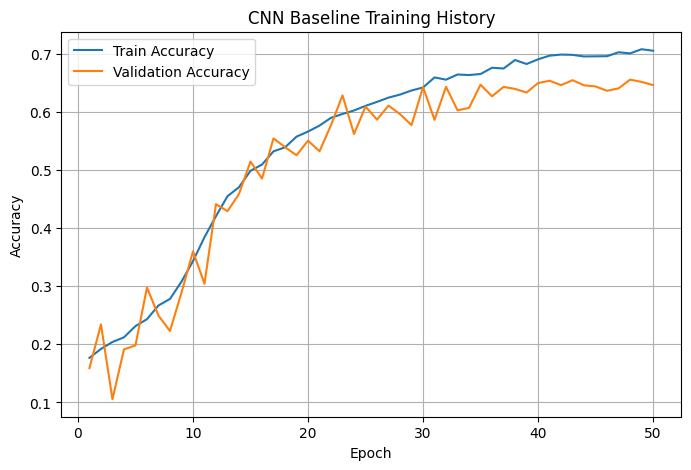

Model saved to: ../models/emotion_cnn_baseline.pth
History saved to: ../results/emotion_cnn_baseline_history.csv
Curve saved to: ../results/emotion_cnn_baseline_curve.png


In [13]:
## save model, history, and curves

history_df = pd.DataFrame(history)
history_df.to_csv(history_save_path, index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc"], label="Train Accuracy")
plt.plot(history_df["epoch"], history_df["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Baseline Training History")
plt.legend()
plt.grid(True)
plt.savefig(curve_save_path, bbox_inches="tight")
plt.show()

print("Model saved to:", model_save_path)
print("History saved to:", history_save_path)
print("Curve saved to:", curve_save_path)